# Wafer resistivity from four-point-probe I–V sweeps

Pipeline: load sweeps --> robust linear fit $V = R\,I + V_0$ --> $\rho = \mathrm{CF}_\mathrm{pos}\, t\, R$ --> per-position and per-wafer summaries --> comparison to manufacturer range → current prediction $I = V/R$.

## Configuration

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

%matplotlib inline

INPUT_DIR   = Path("Data/IV_wafer")
WAFER_TABLE = Path("Data/wafers.csv")
OUTPUT_DIR  = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# rho = CF[position] * t * R   (position-dependent geometric correction factor)
CORRECTION_FACTOR = {"1": 2.866, "2": 3.362}
OUTLIER_NSIGMA    = 5.0      # MAD-based rejection threshold for the refit
V_PROBE           = 1e-3     # V, bias used for the I = V/R prediction

plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "serif", "font.serif": ["STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "legend.fontsize": 7, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "axes.linewidth": 0.8, "lines.linewidth": 1.2,
    "legend.frameon": False,
})

C_DATA, C_FIT, C_EXCL, C_BAND = "black", "#b2182b", "0.6", "0.85"
CMAP = mpl.colormaps["managua"] if "managua" in mpl.colormaps else mpl.colormaps["viridis"]

def savefig(fig, name):
    for ext in ("png","pdf"):
        fig.savefig(OUTPUT_DIR / f"{name}.{ext}")

## Helpers

In [2]:
FNAME_RE = re.compile(r"^(?P<wafer>[A-Za-z]+)(?P<position>\d+)(?:_(?P<range>.+))?$")
RANGE_RE = re.compile(r"^(?P<val>[\d.]+)(?P<unit>uA|mA|A)$")
UNIT_A   = {"uA": 1e-6, "mA": 1e-3, "A": 1.0}


def parse_current_range(tag):
    """'500mA' -> 0.5 (A). NaN if unparseable."""
    m = RANGE_RE.match(tag or "")
    return float(m["val"]) * UNIT_A[m["unit"]] if m else np.nan


def parse_nominal(label):
    """Manufacturer resistivity label -> (lo, hi) in Ohm cm.
    '<=0.01' -> (0, 0.01); '0.001-0.005' -> (0.001, 0.005); missing -> (nan, nan)."""
    if not isinstance(label, str) or not label.strip():
        return np.nan, np.nan
    s = label.replace(" ", "")
    if m := re.fullmatch(r"<=?([\d.eE+]+)", s):
        return 0.0, float(m[1])
    if m := re.fullmatch(r">=?([\d.eE+]+)", s):
        return float(m[1]), np.inf
    if m := re.fullmatch(r"([\d.eE+]+)-([\d.eE+]+)", s):
        return float(m[1]), float(m[2])
    raise ValueError(f"Unrecognised resistivity label: {label!r}")


def spec_tex(label):
    """'<=0.01' -> '$\\leq$ 0.01'; '0.001-0.005' -> '0.001-0.005' (ASCII-safe mathtext)."""
    lo, hi = parse_nominal(label)
    if lo == 0:
        return rf"$\leq$ {hi:g}"
    if np.isinf(hi):
        return rf"$\geq$ {lo:g}"
    return f"{lo:g}-{hi:g}"


def read_iv(path):
    """Instrument CSV -> DataFrame[I_A, V_V]. Header row starts with 'Reading,Unit'."""
    lines = Path(path).read_text().splitlines()
    h = next(i for i, l in enumerate(lines) if l.startswith("Reading,Unit"))
    raw = pd.read_csv(path, skiprows=h)
    return raw[["Value", "Reading"]].rename(columns={"Value": "I_A", "Reading": "V_V"})


def linfit(x, y):
    """OLS y = a x + b. Returns a, b, sigma_a, R^2."""
    n = len(x)
    a, b = np.polyfit(x, y, 1)
    r = y - (a * x + b)
    ss_res = np.sum(r**2)
    ss_tot = np.sum((y - y.mean())**2)
    sxx = np.sum((x - x.mean())**2)
    sig_a = np.sqrt(ss_res / (n - 2) / sxx) if n > 2 else np.nan
    return a, b, sig_a, 1.0 - ss_res / ss_tot


def fit_iv(I, V, nsigma=OUTLIER_NSIGMA):
    """Fit V(I); reject points > nsigma robust-sigma (MAD) from the first fit, then refit."""
    a, b, *_ = linfit(I, V)
    r = V - (a * I + b)
    sigma = 1.4826 * np.median(np.abs(r - np.median(r)))
    keep = np.abs(r - np.median(r)) <= nsigma * sigma if sigma > 0 else np.ones_like(I, bool)
    if keep.sum() < 3:
        keep[:] = True
    a, b, sig_a, r2 = linfit(I[keep], V[keep])
    return dict(R=a, V0=b, sigma_R=sig_a, R2=r2, keep=keep, resid=V - (a * I + b))


def si_prefix(x):
    """Pick an SI prefix so max|x| lies in [1, 1000). Returns (scale, mathtext prefix)."""
    m = np.nanmax(np.abs(x))
    for s, p in [(1, ""), (1e-3, "m"), (1e-6, r"\mu "), (1e-9, "n")]:
        if m >= s:
            return 1 / s, p
    return 1e9, "n"


def fmt_r2(r2):
    """Enough decimals that R^2 is not rounded to 1."""
    d = 4 if r2 >= 1 else max(4, int(np.ceil(-np.log10(1 - r2))) + 2)
    return f"{r2:.{d}f}"

## Wafer table (manufacturer specification)

In [3]:
wafers = (
    pd.read_csv(WAFER_TABLE)
      .rename(columns={"label": "wafer", "resistivity_ohm_cm": "rho_nominal_label"})
      .assign(wafer=lambda d: d["wafer"].str.strip().str.lower(),
              id=lambda d: d["id"].astype("Int64"),
              thickness_cm=lambda d: d["thickness_um"] * 1e-4)
)
wafers[["rho_nom_lo", "rho_nom_hi"]] = wafers["rho_nominal_label"].apply(
    lambda s: pd.Series(parse_nominal(s)))
wafers = wafers.set_index("wafer")
wafers

,id,thickness_um,rho_nominal_label,thickness_cm,rho_nom_lo,rho_nom_hi
wafer,,,,,,
a,4058,525.0,<=0.01,0.0525,0.000,0.010
b,2167,500.0,0.001-0.005,0.0500,0.001,0.005
c,1317,1000.0,1-10,0.1000,1.000,10.000
d,4145,525.0,5-15,0.0525,5.000,15.000
e,3953,500.0,10-20,0.0500,10.000,20.000
f,3872,525.0,0-100,0.0525,0.000,100.000
g,785,500.0,0.001-0.005,0.0500,0.001,0.005
h,783,500.0,1-10,0.0500,1.000,10.000
i,1575,525.0,0.01-0.02,0.0525,0.010,0.020


## Load and fit all sweeps

In [4]:
fits, rows = [], []
for path in sorted(INPUT_DIR.glob("*.csv")):
    m = FNAME_RE.match(path.stem)
    if not m:
        print(f"skip (name): {path.name}"); continue
    wafer, pos = m["wafer"].lower(), m["position"]
    if wafer not in wafers.index:
        print(f"skip (no wafer entry '{wafer}'): {path.name}"); continue

    df = read_iv(path)
    I, V = df["I_A"].to_numpy(), df["V_V"].to_numpy()
    f = fit_iv(I, V)
    info = wafers.loc[wafer]
    cf = CORRECTION_FACTOR.get(pos, np.nan)
    rho = cf * info["thickness_cm"] * f["R"]

    fits.append(dict(file=path.name, wafer=wafer, position=pos, id=info["id"],
                     I=I, V=V, rho=rho, **f))
    rows.append(dict(
        wafer=wafer, position=pos, id=info["id"], file=path.name,
        current_range_A=parse_current_range(m["range"]),
        R_ohm=f["R"], sigma_R_ohm=f["sigma_R"], V0_V=f["V0"],
        R2=f["R2"], one_minus_R2=1 - f["R2"],
        rho_meas_ohm_cm=rho, sigma_rho_stat_ohm_cm=cf * info["thickness_cm"] * f["sigma_R"],
        n_used=int(f["keep"].sum()), n_rejected=int((~f["keep"]).sum()),
    ))

per_file = (pd.DataFrame(rows)
              .sort_values(["wafer", "position", "current_range_A"])
              .reset_index(drop=True))
fits.sort(key=lambda d: (d["wafer"], d["position"], parse_current_range(FNAME_RE.match(Path(d["file"]).stem)["range"])))
per_file

,wafer,position,id,file,current_range_A,R_ohm,sigma_R_ohm,V0_V,R2,one_minus_R2,rho_meas_ohm_cm,sigma_rho_stat_ohm_cm,n_used,n_rejected
0,a,1,4058,a1_500mA.csv,0.500000,0.008756,0.000063,0.000161,0.998875,1.124741e-03,0.001318,0.000009,24,1
1,a,2,4058,a2_10mA.csv,0.010000,0.008259,0.000126,0.000004,0.996048,3.952208e-03,0.001458,0.000022,19,2
2,a,2,4058,a2_100mA.csv,0.100000,0.008113,0.000560,-0.000002,0.916887,8.311331e-02,0.001432,0.000099,21,0
3,a,2,4058,a2_500mA.csv,0.500000,0.007674,0.000068,0.000086,0.992446,7.553753e-03,0.001354,0.000012,100,1
4,a,2,4058,a2_1A.csv,1.000000,0.007378,0.000189,0.000043,0.987633,1.236691e-02,0.001302,0.000033,21,0
5,b,1,2167,b1_500mA.csv,0.500000,0.025629,0.000031,-0.000112,0.999967,3.281007e-05,0.003673,0.000004,25,0
6,b,2,2167,b2_500mA.csv,0.500000,0.021720,0.000040,-0.000043,0.999835,1.648434e-04,0.003651,0.000007,50,1
7,b,2,2167,b2_1A.csv,1.000000,0.023377,0.000181,0.000519,0.994231,5.769054e-03,0.003930,0.000030,99,1
8,g,1,785,g1_500mA.csv,0.500000,0.020407,0.000057,0.000104,0.999822,1.783653e-04,0.002924,0.000008,25,0
9,g,2,785,g2_50mA.csv,0.050000,0.018406,0.000447,-0.000025,0.987210,1.278999e-02,0.003094,0.000075,24,1


## Per-position and per-wafer summaries

$R$ is averaged per probe position only: the correction factor differs between positions, so a wafer-level mean of $R$ has no physical meaning. The wafer-level $\rho$ is the mean of the position means (each position weighted equally); the quoted spread is the standard deviation over all sweeps on that wafer.

In [5]:
per_position = (
    per_file.groupby(["wafer", "position"])
      .agg(id=("id", "first"), n_files=("file", "count"),
           R_mean_ohm=("R_ohm", "mean"), R_std_ohm=("R_ohm", "std"),
           rho_mean_ohm_cm=("rho_meas_ohm_cm", "mean"), rho_std_ohm_cm=("rho_meas_ohm_cm", "std"),
           R2_min=("R2", "min"))
      .reset_index()
)

spread = per_file.groupby("wafer")["rho_meas_ohm_cm"].std().rename("rho_meas_std_ohm_cm")
wafer_summary = (
    per_position.groupby("wafer")
      .agg(id=("id", "first"), n_positions=("position", "nunique"), n_files=("n_files", "sum"),
           rho_meas_ohm_cm=("rho_mean_ohm_cm", "mean"), R2_min=("R2_min", "min"))
      .join(spread)
      .join(wafers[["rho_nominal_label", "rho_nom_lo", "rho_nom_hi"]])
      .reset_index()
)

def spec_status(r):
    x, lo, hi, s = r["rho_meas_ohm_cm"], r["rho_nom_lo"], r["rho_nom_hi"], r["rho_meas_std_ohm_cm"]
    if pd.isna(x) or pd.isna(hi):
        return "n/a"
    if lo <= x <= hi:
        return "within"
    s = 0.0 if pd.isna(s) else s
    edge = "within 1 sigma" if (x + s >= lo and x - s <= hi) else "outside"
    return f"{'below' if x < lo else 'above'} ({edge})"

wafer_summary["spec_status"] = wafer_summary.apply(spec_status, axis=1)

per_file.to_csv(OUTPUT_DIR / "iv_fits_per_file.csv", index=False)
per_position.to_csv(OUTPUT_DIR / "iv_summary_per_position.csv", index=False)
wafer_summary.to_csv(OUTPUT_DIR / "iv_summary_per_wafer.csv", index=False)

display(per_position)
wafer_summary

,wafer,position,id,n_files,R_mean_ohm,R_std_ohm,rho_mean_ohm_cm,rho_std_ohm_cm,R2_min
0,a,1,4058,1,0.008756,NaN,0.001318,NaN,0.998875
1,a,2,4058,4,0.007856,0.000404,0.001387,0.000071,0.916887
2,b,1,2167,1,0.025629,NaN,0.003673,NaN,0.999967
3,b,2,2167,2,0.022548,0.001172,0.003790,0.000197,0.994231
4,g,1,785,1,0.020407,NaN,0.002924,NaN,0.999822
5,g,2,785,3,0.017957,0.000435,0.003019,0.000073,0.987210
6,i,2,1575,4,0.085820,0.010014,0.015148,0.001768,0.899486
7,z,2,None,4,57.142347,0.593212,NaN,NaN,0.973594


,wafer,id,n_positions,n_files,rho_meas_ohm_cm,R2_min,rho_meas_std_ohm_cm,rho_nominal_label,rho_nom_lo,rho_nom_hi,spec_status
0,a,4058,2,5,0.001352,0.916887,0.000069,<=0.01,0.000,0.010,within
1,b,2167,2,3,0.003731,0.994231,0.000155,0.001-0.005,0.001,0.005,within
2,g,785,2,4,0.002971,0.987210,0.000076,0.001-0.005,0.001,0.005,within
3,i,1575,1,4,0.015148,0.899486,0.001768,0.01-0.02,0.010,0.020,within
4,z,None,1,4,NaN,0.973594,NaN,NaN,NaN,NaN,n/a


## I–V fits with residuals

One figure per wafer. Upper panels: sweep and linear fit. Lower panels: residuals, with the grey band marking $\pm$ RMS of the retained points.

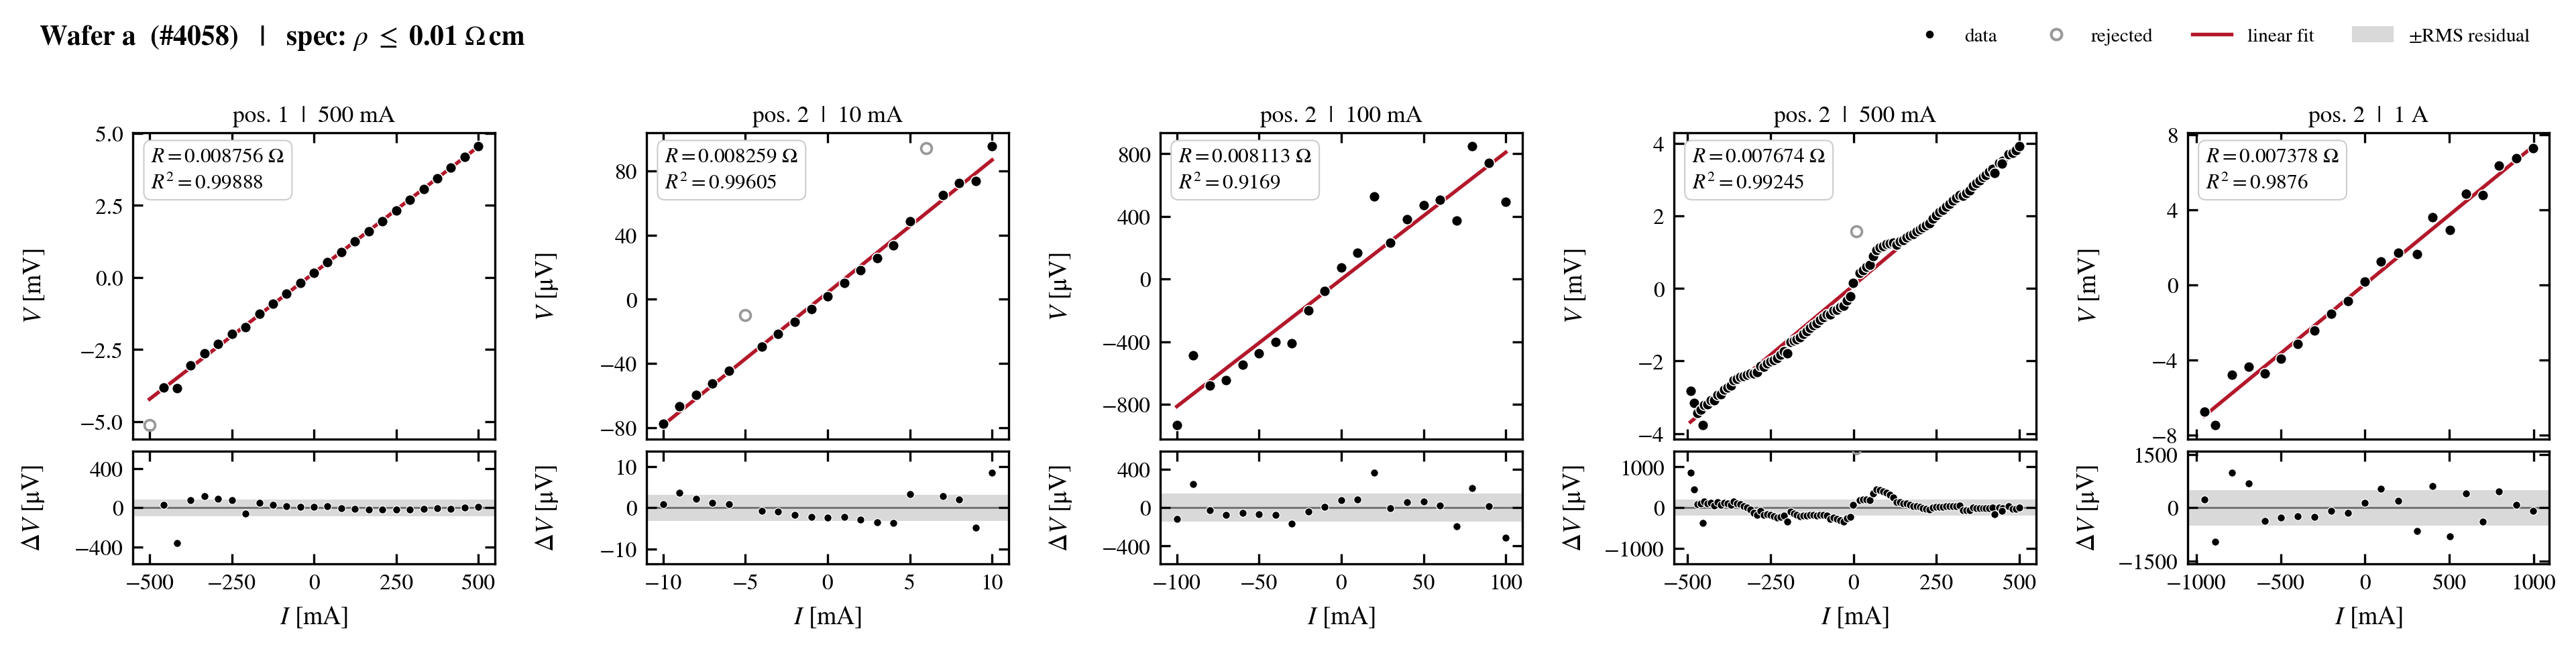

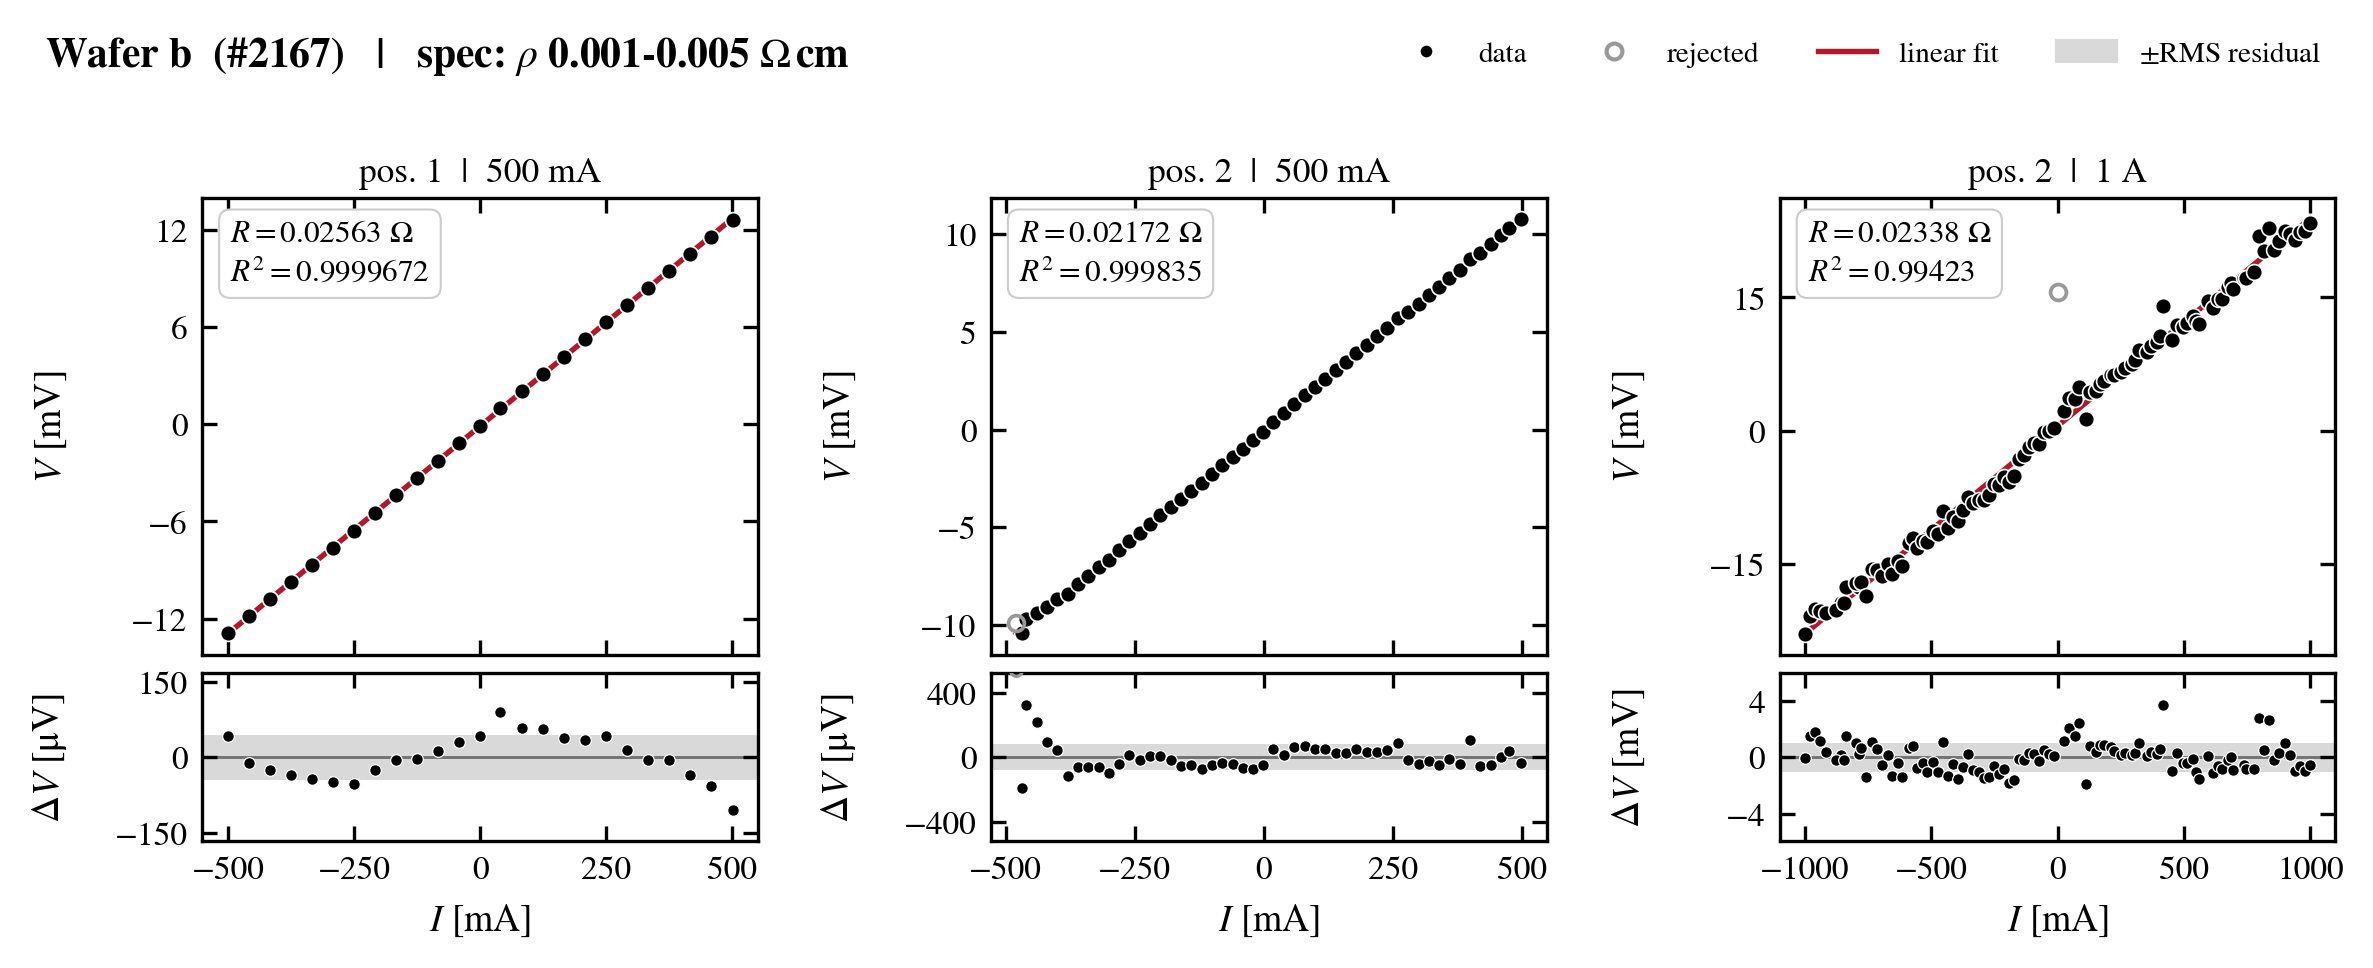

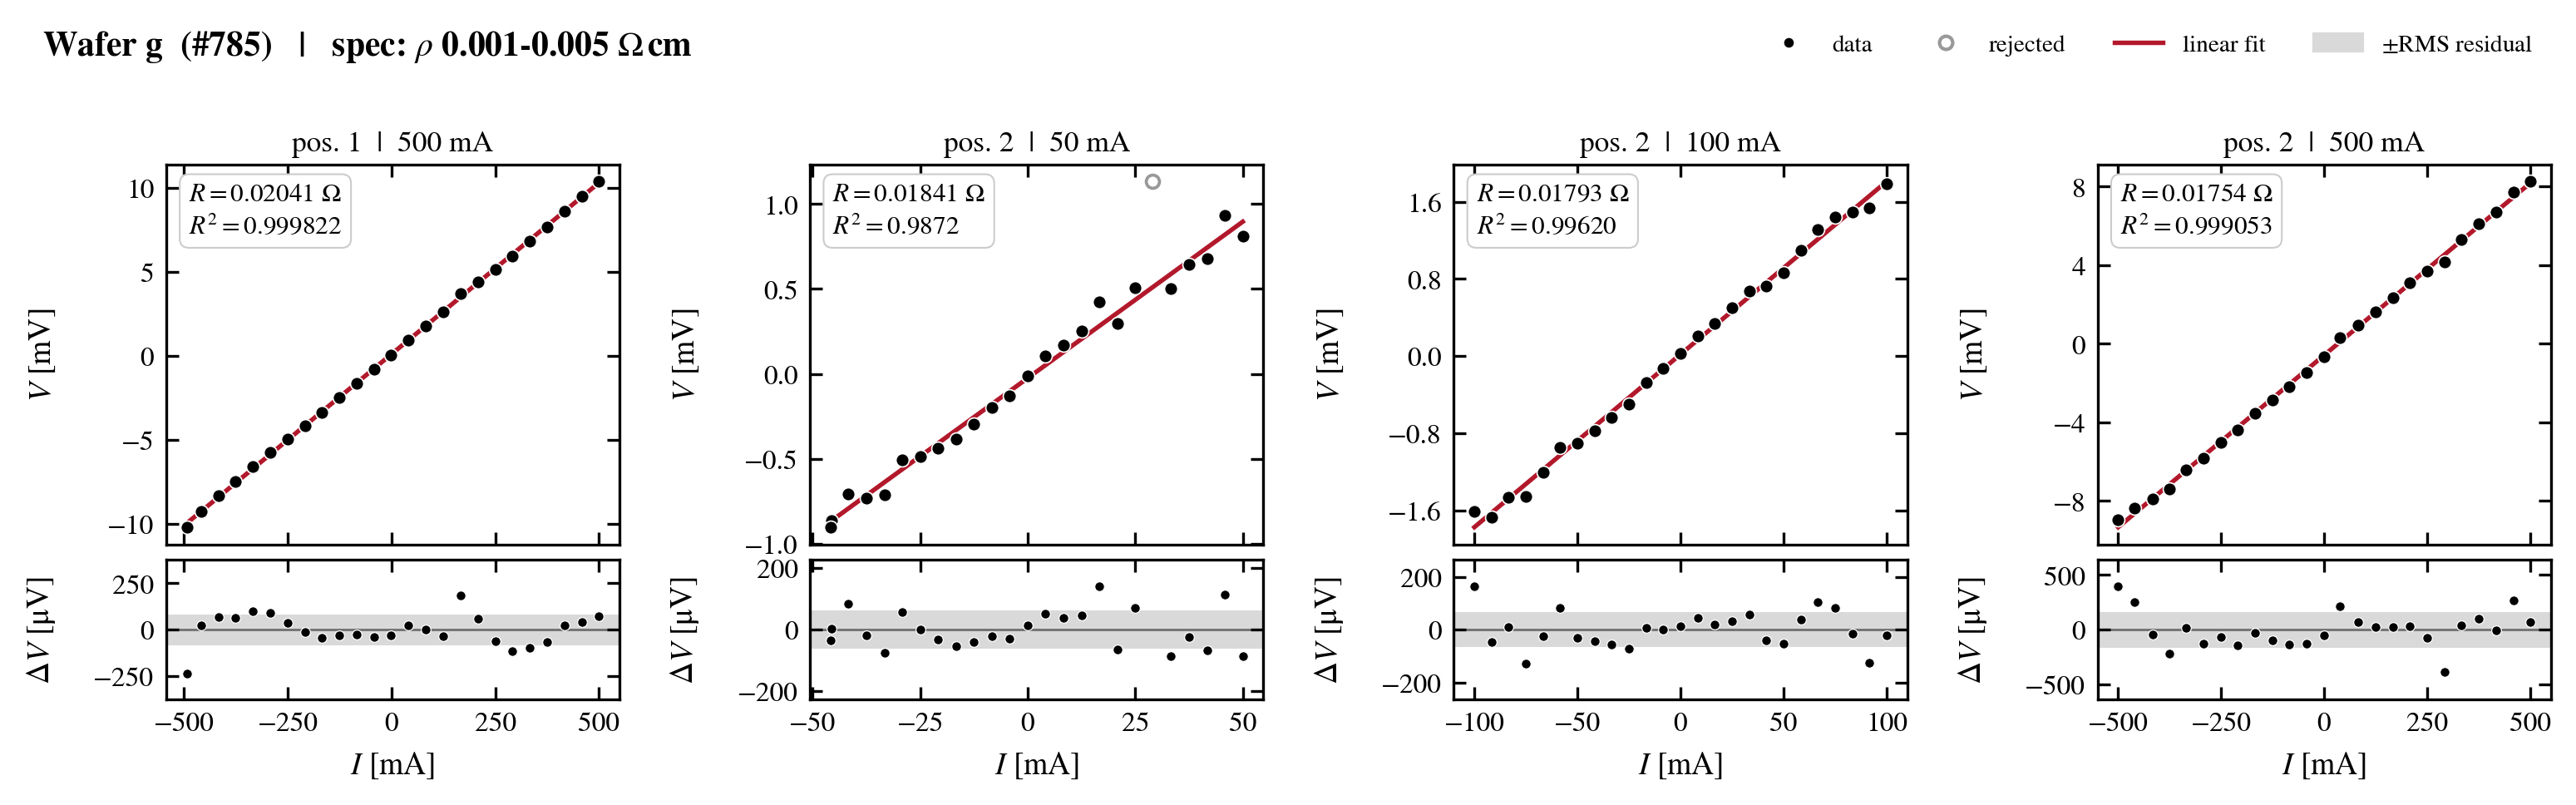

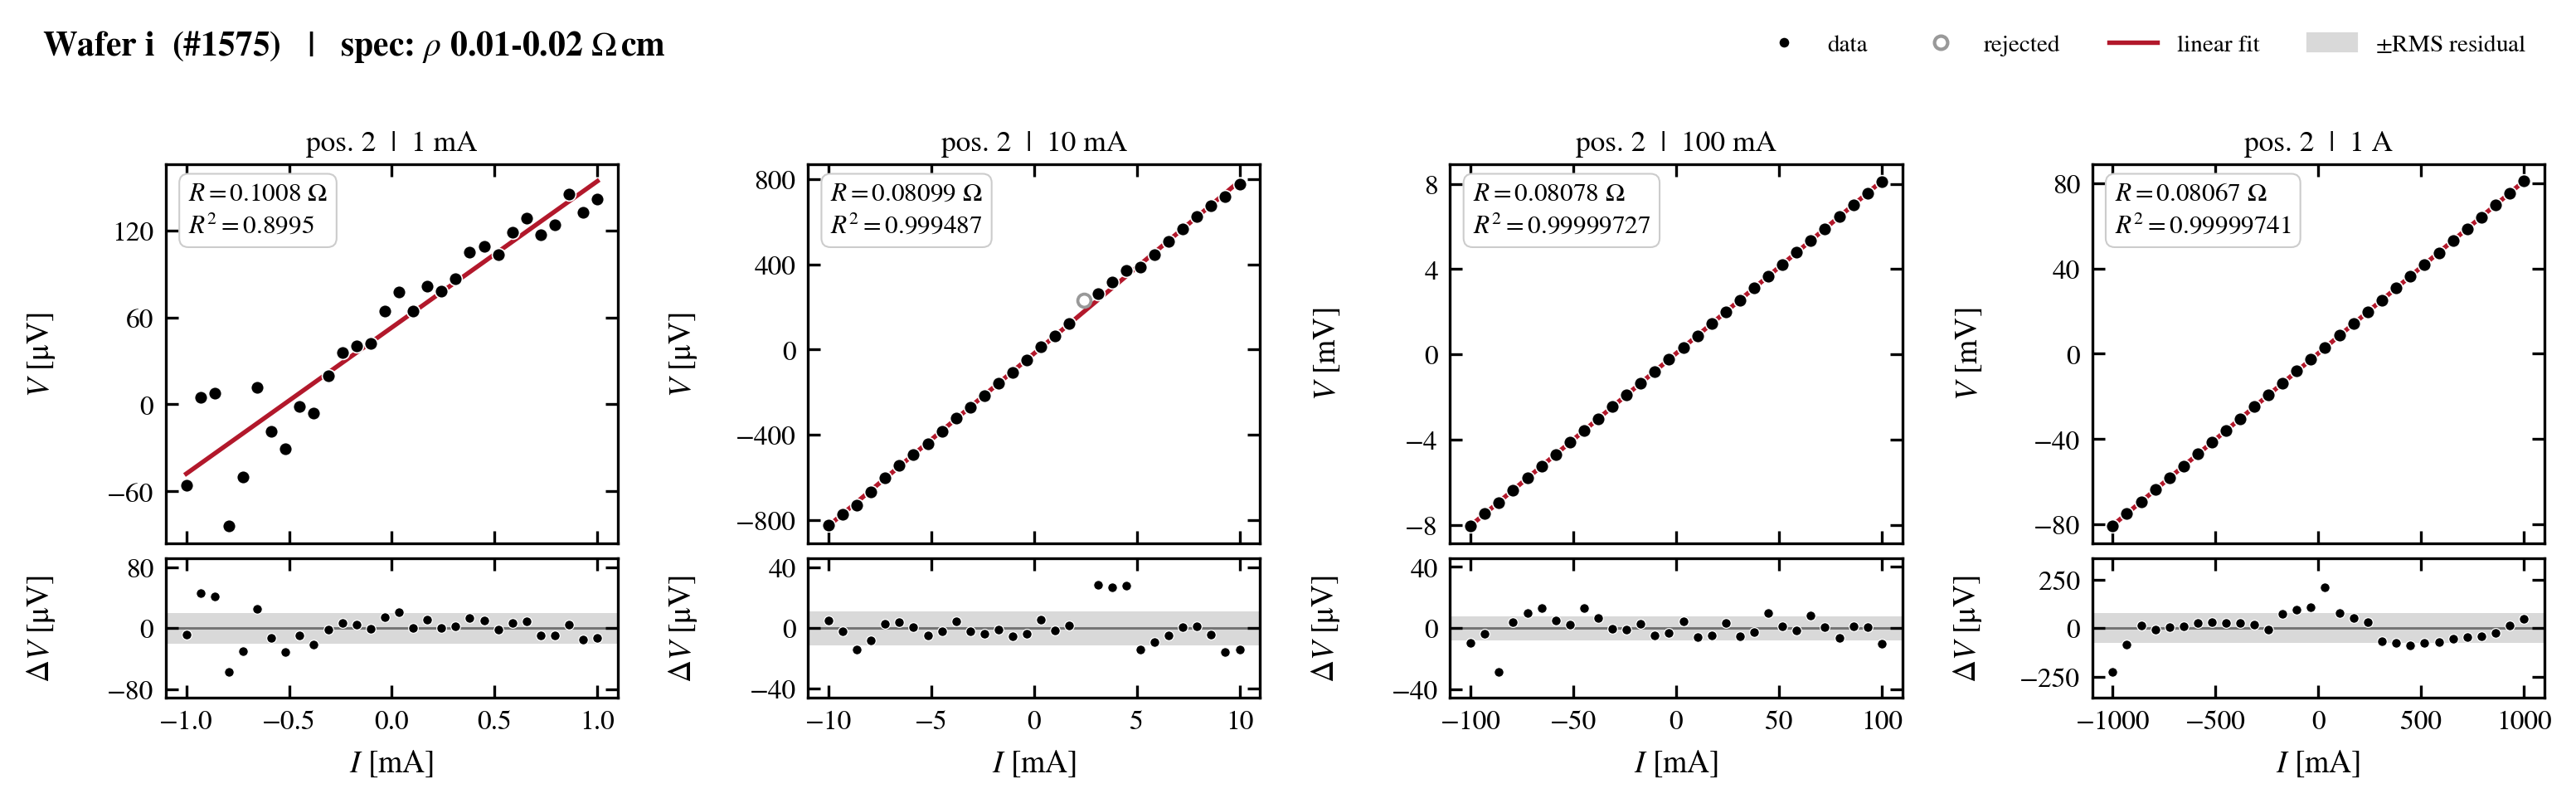

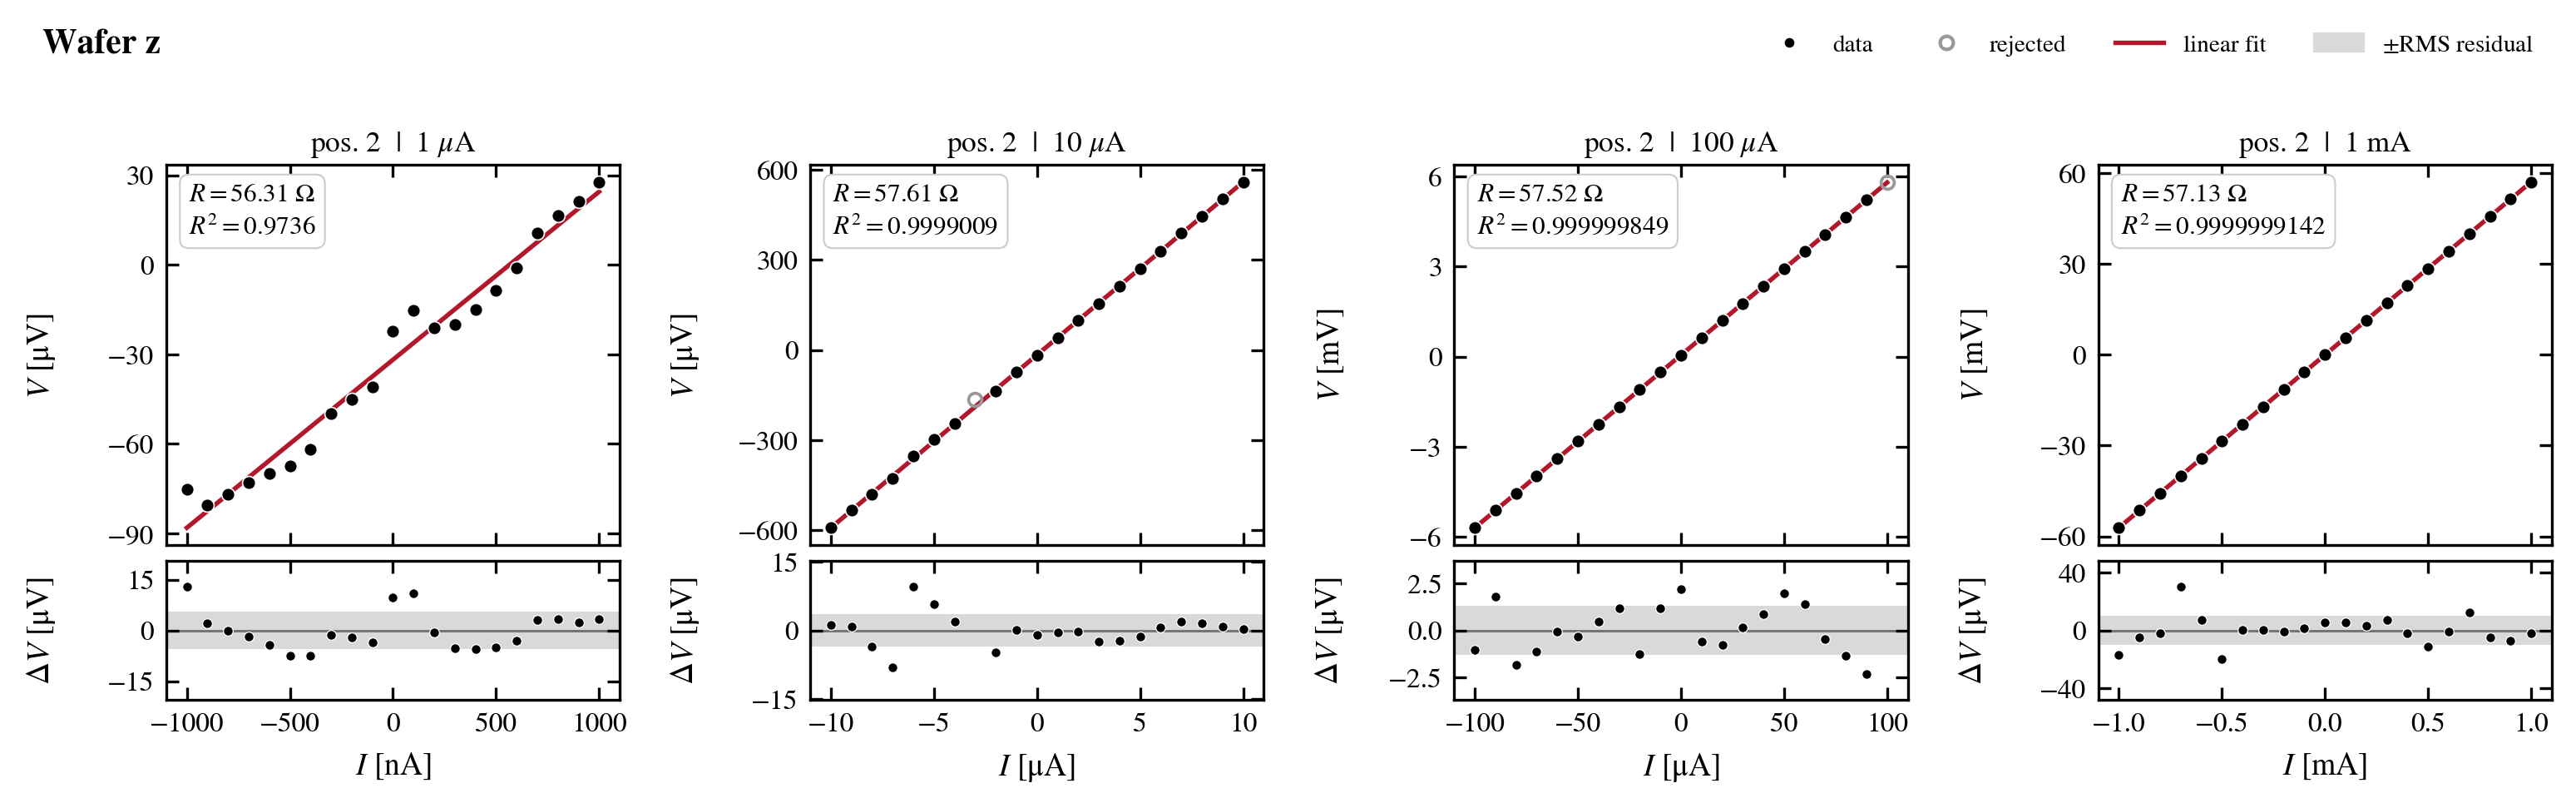

In [6]:
def plot_fit(ax, axr, f):
    I, V, keep, res = f["I"], f["V"], f["keep"], f["resid"]
    si, pi = si_prefix(I); sv, pv = si_prefix(V); sr, pr = si_prefix(res[keep])
    Is, Vs, Rs = I * si, V * sv, res * sr

    x = np.array([I.min(), I.max()])
    ax.plot(x * si, (f["R"] * x + f["V0"]) * sv, color=C_FIT, lw=1.3, zorder=2)
    ax.plot(Is[keep], Vs[keep], "o", ms=3.8, mfc=C_DATA, mec="white", mew=0.4, zorder=3)
    if (~keep).any():
        ax.plot(Is[~keep], Vs[~keep], "o", ms=3.8, mfc="none", mec=C_EXCL, mew=0.9, zorder=3)

    txt = rf"$R = {f['R']:.4g}\ \Omega$" + "\n" + rf"$R^2 = {fmt_r2(f['R2'])}$"
    ax.text(0.05, 0.95, txt, transform=ax.transAxes, va="top", ha="left", fontsize=7.5,
            linespacing=1.4, bbox=dict(fc="white", ec="0.8", lw=0.5, boxstyle="round,pad=0.35"))
    rng_tag = FNAME_RE.match(Path(f["file"]).stem)["range"] or ""
    rng_tag = re.sub(r"^([\d.]+)", r"\1 ", rng_tag).replace("uA", r"$\mu$A")
    ax.set_title(f"pos. {f['position']}  |  {rng_tag}", fontsize=8.5, pad=4)
    ax.set_ylabel(rf"$V$ [$\mathrm{{{pv}V}}$]")
    ax.tick_params(labelbottom=False)
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(5))

    rms = np.sqrt(np.mean(Rs[keep] ** 2))
    axr.axhspan(-rms, rms, color=C_BAND, lw=0, zorder=0)
    axr.axhline(0, color="0.45", lw=0.7, zorder=1)
    axr.plot(Is[keep], Rs[keep], "o", ms=2.8, mfc=C_DATA, mec="white", mew=0.3, zorder=3)
    if (~keep).any():
        axr.plot(Is[~keep], Rs[~keep], "o", ms=2.8, mfc="none", mec=C_EXCL, mew=0.8, zorder=3)
    lim = 1.6 * np.max(np.abs(Rs[keep]))   # rejected points never set the scale
    axr.set_ylim(-lim, lim)
    axr.yaxis.set_major_locator(mpl.ticker.MaxNLocator(3, symmetric=True))
    axr.xaxis.set_major_locator(mpl.ticker.MaxNLocator(5, symmetric=True))
    axr.set_xlabel(rf"$I$ [$\mathrm{{{pi}A}}$]")
    axr.set_ylabel(rf"$\Delta V$ [$\mathrm{{{pr}V}}$]")


def plot_wafer(wafer):
    wf = [f for f in fits if f["wafer"] == wafer]
    n = len(wf)
    W = 2.45 * n + 0.5
    fig = plt.figure(figsize=(W, 3.3))
    gs = GridSpec(2, n, figure=fig, height_ratios=[3, 1.1], hspace=0.06, wspace=0.42,
                  left=0.62 / W, right=1 - 0.12 / W, top=0.80, bottom=0.15)
    for k, f in enumerate(wf):
        ax = fig.add_subplot(gs[0, k]); axr = fig.add_subplot(gs[1, k], sharex=ax)
        plot_fit(ax, axr, f)
        for a_ in (ax, axr):
            a_.yaxis.set_label_coords(-0.24, 0.5)

    info = wafers.loc[wafer]
    head = f"Wafer {wafer}" + ("" if pd.isna(info["id"]) else f"  (#{info['id']})")
    if isinstance(info["rho_nominal_label"], str):
        head += rf"   |   spec: $\rho$ {spec_tex(info['rho_nominal_label'])} $\Omega\,$cm"
    fig.text(0.012, 0.965, head, ha="left", va="top", fontsize=10, weight="bold")
    handles = [Line2D([], [], ls="", marker="o", ms=3.8, mfc=C_DATA, mec="white", label="data"),
               Line2D([], [], ls="", marker="o", ms=3.8, mfc="none", mec=C_EXCL, label="rejected"),
               Line2D([], [], color=C_FIT, lw=1.3, label="linear fit"),
               Patch(color=C_BAND, label=r"$\pm$RMS residual")]
    fig.legend(handles=handles, loc="upper right", ncol=4, fontsize=7, bbox_to_anchor=(0.99, 0.985))
    return fig


for w in dict.fromkeys(f["wafer"] for f in fits):
    fig = plot_wafer(w)
    #savefig(fig, f"iv_fits_wafer_{w}")
    plt.show()

## Measured resistivity vs manufacturer specification

Grey band: manufacturer range (open-ended for $\leq$ labels). Grey markers: individual sweeps. Red: wafer mean $\pm$ std over sweeps.

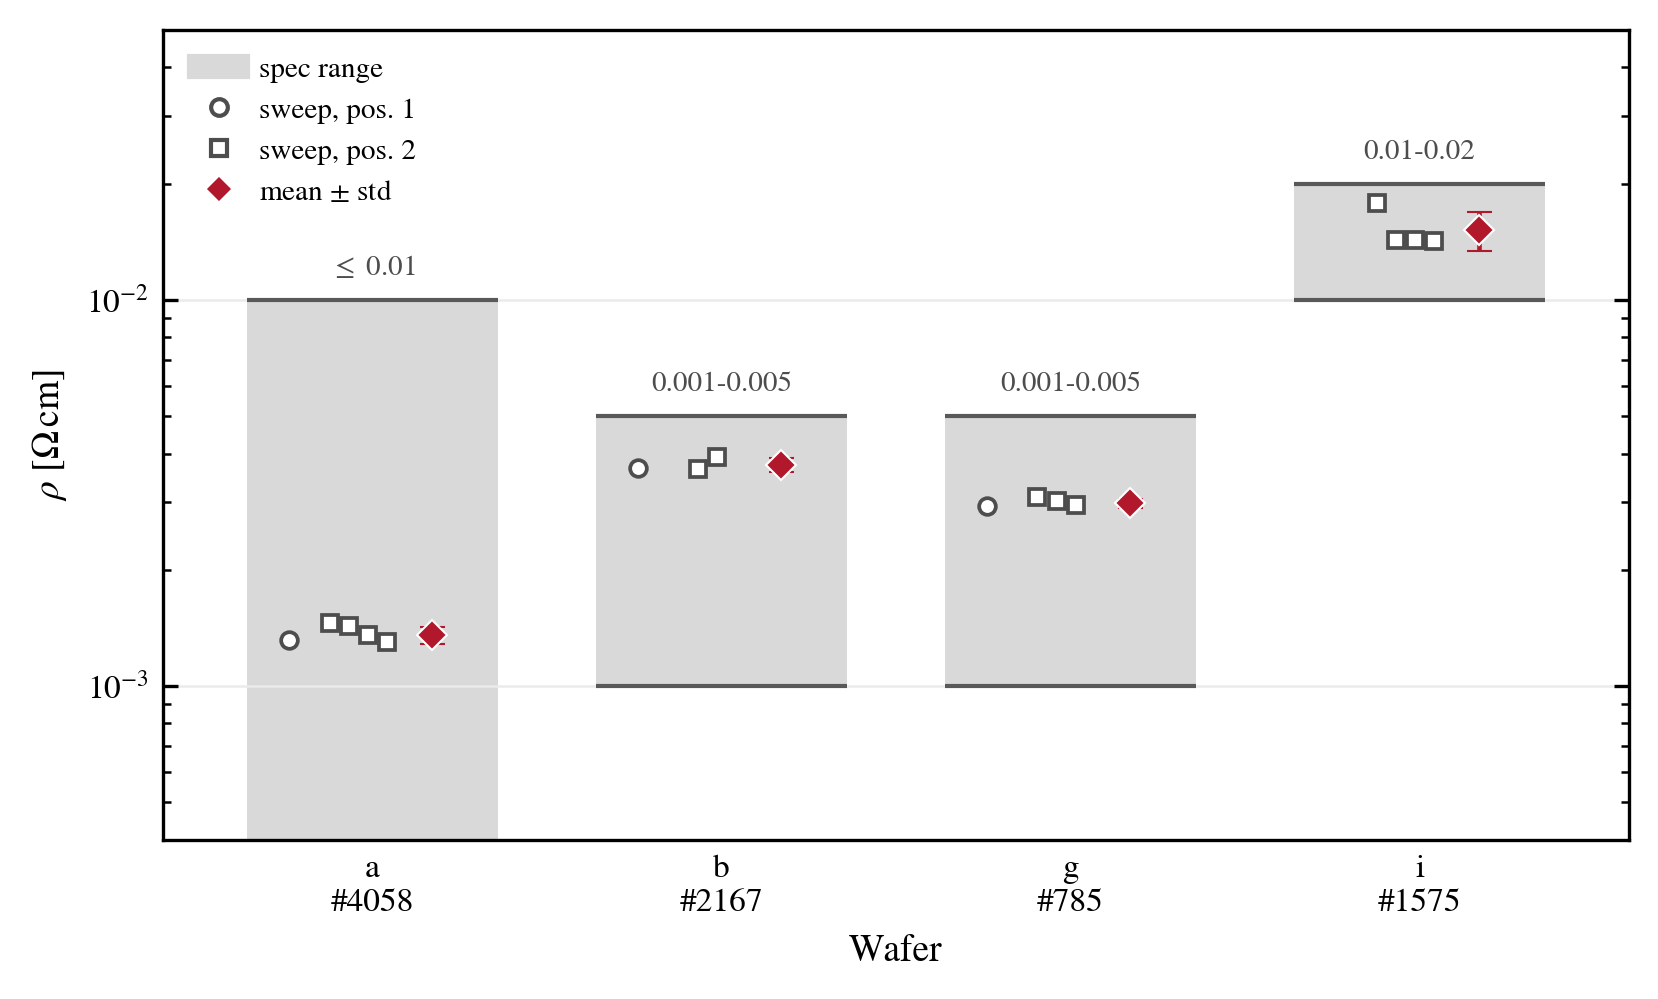

,wafer,id,rho_meas_ohm_cm,rho_meas_std_ohm_cm,rho_nominal_label,spec_status
0,a,4058,0.001352,0.000069,<=0.01,within
1,b,2167,0.003731,0.000155,0.001-0.005,within
2,g,785,0.002971,0.000076,0.001-0.005,within
3,i,1575,0.015148,0.001768,0.01-0.02,within


In [7]:
ws = wafer_summary.dropna(subset=["rho_meas_ohm_cm"]).reset_index(drop=True)
pf = per_file.dropna(subset=["rho_meas_ohm_cm"])
x_of = {w: k for k, w in enumerate(ws["wafer"])}
POS_MARKER = {"1": "o", "2": "s"}

y_all = np.r_[pf["rho_meas_ohm_cm"], ws["rho_nom_lo"], ws["rho_nom_hi"]]
y_all = y_all[np.isfinite(y_all) & (y_all > 0)]
ylo, yhi = y_all.min() / 2.5, y_all.max() * 2.5

fig, ax = plt.subplots(figsize=(1.05 * len(ws) + 1.4, 3.4))
hw = 0.36
for k, r in ws.iterrows():
    lo, hi = r["rho_nom_lo"], r["rho_nom_hi"]
    if not np.isfinite(hi):
        continue
    open_low = lo <= 0
    y0, y1 = (ylo if open_low else lo), min(hi, yhi)
    ax.fill_between([k - hw, k + hw], y0, y1, color=C_BAND, lw=0, zorder=1)
    ax.hlines(y1, k - hw, k + hw, color="0.35", lw=1.0, zorder=2)
    if not open_low:
        ax.hlines(y0, k - hw, k + hw, color="0.35", lw=1.0, zorder=2)
    ax.text(k, y1 * 1.12, spec_tex(r["rho_nominal_label"]), ha="center", va="bottom",
            fontsize=7, color="0.3")

for pos, g in pf.groupby("position"):
    off = {"1": -0.24, "2": -0.04}.get(pos, 0.0)
    jit = g.groupby("wafer").cumcount() - (g.groupby("wafer")["file"].transform("count") - 1) / 2
    xs = g["wafer"].map(x_of) + off + 0.055 * jit
    ax.plot(xs, g["rho_meas_ohm_cm"], POS_MARKER.get(pos, "^"), ms=4, ls="",
            mfc="white", mec="0.3", mew=0.9, zorder=3)

ax.errorbar(ws.index + 0.17, ws["rho_meas_ohm_cm"], yerr=ws["rho_meas_std_ohm_cm"].fillna(0),
            fmt="D", ms=5, color=C_FIT, mec="white", mew=0.5, capsize=3, elinewidth=1.1, zorder=4)

ax.set_yscale("log")
ax.set_ylim(ylo, yhi)
ax.set_xlim(-0.6, len(ws) - 0.4)
ax.set_xticks(ws.index)
ax.set_xticklabels([f"{w}\n#{i}" if pd.notna(i) else w for w, i in zip(ws["wafer"], ws["id"])])
ax.set_xlabel("Wafer")
ax.set_ylabel(r"$\rho$ [$\Omega\,$cm]")
ax.tick_params(axis="x", which="both", top=False, bottom=False)
ax.grid(axis="y", which="major", color="0.92", lw=0.6, zorder=0)

handles = [Patch(color=C_BAND, label="spec range"),
           *[Line2D([], [], ls="", marker=m, ms=4, mfc="white", mec="0.3", label=f"sweep, pos. {p}")
             for p, m in POS_MARKER.items() if p in set(pf["position"])],
           Line2D([], [], ls="", marker="D", ms=5, color=C_FIT, mec="white", label=r"mean $\pm$ std")]
ax.legend(handles=handles, loc="upper left", fontsize=7, handletextpad=0.4)
fig.tight_layout()
#savefig(fig, "resistivity_vs_spec")
plt.show()

ws[["wafer", "id", "rho_meas_ohm_cm", "rho_meas_std_ohm_cm", "rho_nominal_label", "spec_status"]]

## Stability across source-current range

Each panel is one wafer: measured $\rho$ for every sweep against the source current used. A correct four-point measurement of an ohmic sample gives a flat line; a sweep that drifts away (typically at the lowest range, where the voltage is only a few $\mu$ V) is a measurement artefact and a candidate for exclusion. Red line and band: wafer mean $\pm$ std. (Spec comparison is in the previous figure.)

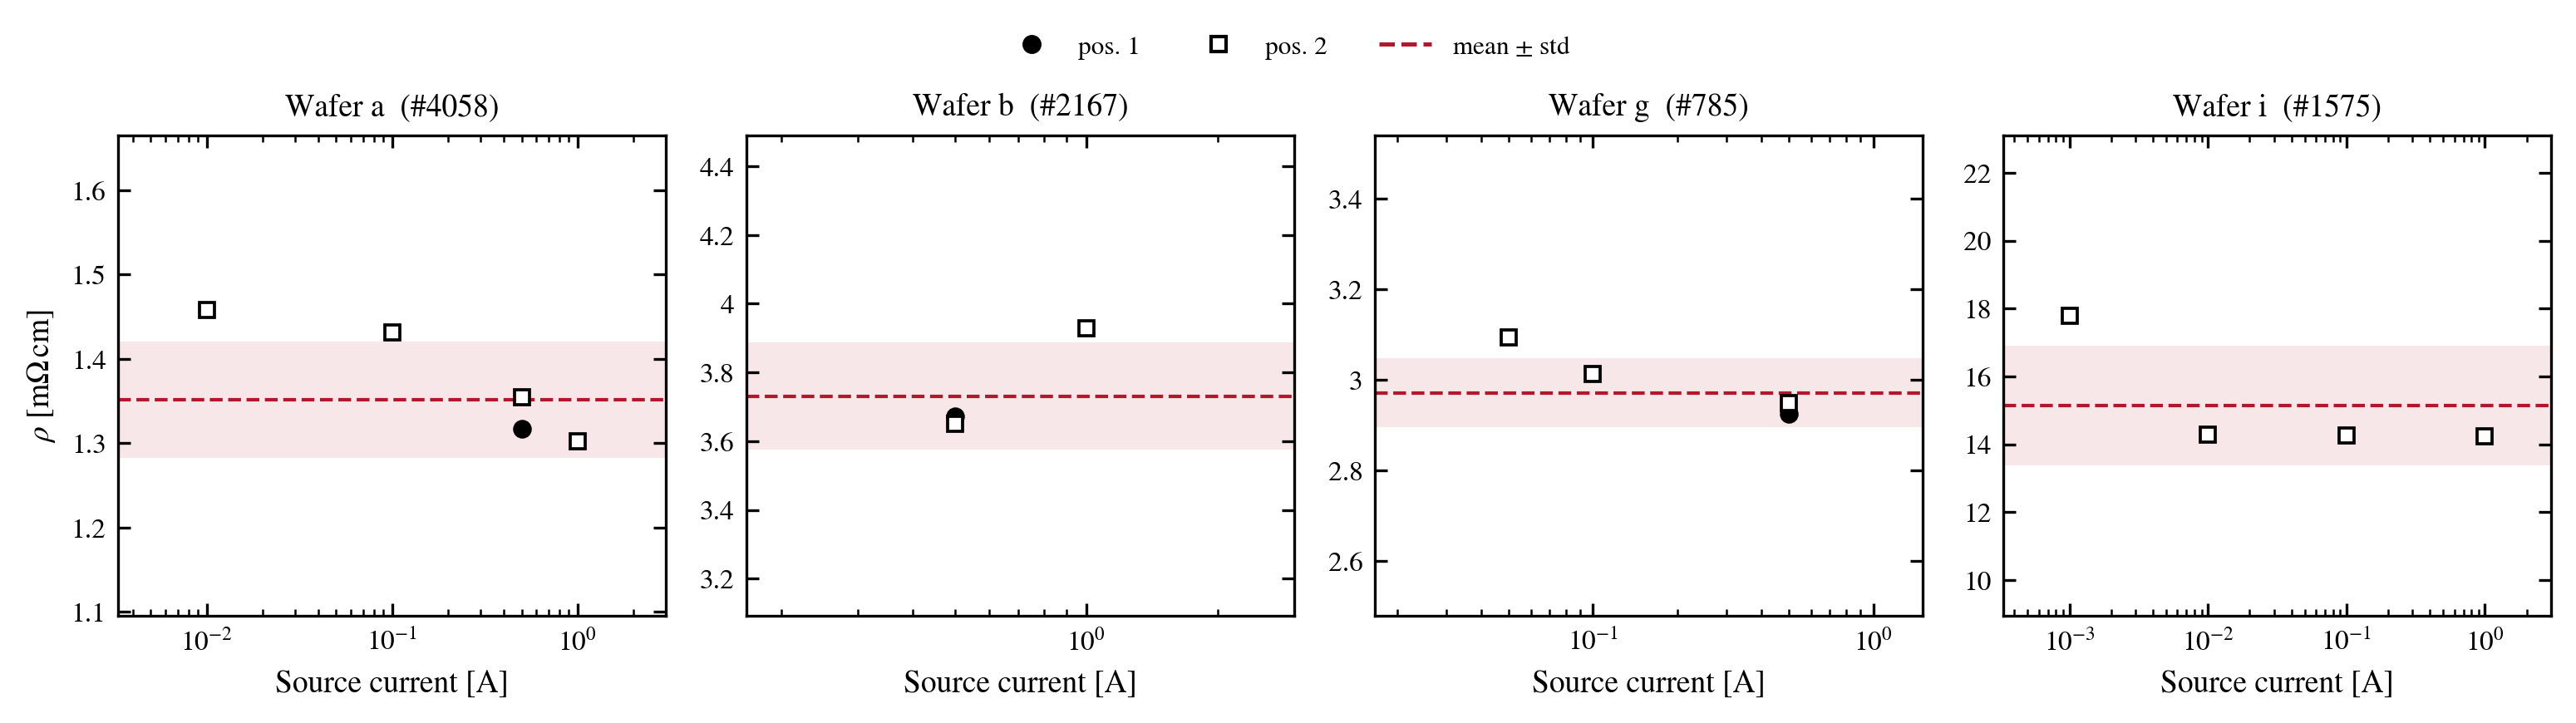

In [8]:
ws_w = list(ws["wafer"])
fig, axes = plt.subplots(1, len(ws_w), figsize=(2.6 * len(ws_w), 2.7), squeeze=False)
for ax, w in zip(axes[0], ws_w):
    g = pf[pf["wafer"] == w]
    r = wafer_summary.set_index("wafer").loc[w]
    m, sd = r["rho_meas_ohm_cm"], np.nan_to_num(r["rho_meas_std_ohm_cm"])

    xr = np.array([g["current_range_A"].min() / 3, g["current_range_A"].max() * 3])
    ax.fill_between(xr, m - sd, m + sd, color=C_FIT, alpha=0.10, lw=0, zorder=1)
    ax.axhline(m, color=C_FIT, lw=1.0, ls="--", zorder=2)
    for pos, gp in g.groupby("position"):
        ax.plot(gp["current_range_A"], gp["rho_meas_ohm_cm"], POS_MARKER.get(pos, "^"),
                ms=4.5, mfc=C_DATA if pos == "1" else "white", mec=C_DATA, mew=0.9, ls="", zorder=3)

    ax.set_xscale("log"); ax.set_xlim(*xr)
    pad = max(3 * sd, 0.15 * m)
    ax.set_ylim(max(0, g["rho_meas_ohm_cm"].min() - pad), g["rho_meas_ohm_cm"].max() + pad)
    ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v * 1e3:g}"))
    ax.set_title(f"Wafer {w}" + ("" if pd.isna(r["id"]) else f"  (#{r['id']})"), fontsize=9)
    ax.set_xlabel("Source current [A]")
axes[0, 0].set_ylabel(r"$\rho$ [m$\Omega\,$cm]")

handles = [Line2D([], [], ls="", marker="o", ms=4.5, color=C_DATA, label="pos. 1"),
           Line2D([], [], ls="", marker="s", ms=4.5, mfc="white", mec=C_DATA, label="pos. 2"),
           Line2D([], [], color=C_FIT, ls="--", label=r"mean $\pm$ std")]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=7.5, bbox_to_anchor=(0.5, 1.07))
fig.tight_layout()
#savefig(fig, "rho_vs_source_current")
plt.show()

## Source current needed for a target probe voltage

In the four-point geometry $R = V/I$ is the transfer resistance between the voltage probes, so $I = V_\mathrm{target}/R$ is the **source current required to read** $V_\mathrm{target}$ across the inner probes. This is a measurement-planning number (which current range to use), not the current the wafer would carry under a bias $V$ in a device.

From the measured $R$ (per position) and, for comparison, from the spec range via $R = \rho/(\mathrm{CF}\,t)$. `range_to_use` is the smallest source range already used in this dataset that reaches $V_\mathrm{target}$.

In [9]:
V_TARGET = 1e-3   # V; ~1 mV keeps the reading well above the uV-level offsets seen in the residuals

RANGES_A = np.sort(per_file["current_range_A"].dropna().unique())

def fmt_A(x):
    if not np.isfinite(x):
        return "-"
    s, p = si_prefix(np.array([x]))
    return f"{x * s:.3g} {p.replace(chr(92) + 'mu ', 'u')}A"

def range_to_use(I):
    ok = RANGES_A[RANGES_A >= I]
    return ok.min() if ok.size else np.nan

pred = per_position.merge(wafers[["thickness_cm", "rho_nom_lo", "rho_nom_hi"]],
                          left_on="wafer", right_index=True)
cf_t = pred["position"].map(CORRECTION_FACTOR) * pred["thickness_cm"]
pred["I_needed_A"] = V_TARGET / pred["R_mean_ohm"]
with np.errstate(divide="ignore"):
    pred["I_spec_min_A"] = V_TARGET * cf_t / pred["rho_nom_hi"]                  # most resistive in spec
    pred["I_spec_max_A"] = V_TARGET * cf_t / pred["rho_nom_lo"].replace(0, np.nan)  # least resistive; none for <= labels
pred["range_to_use_A"] = pred["I_needed_A"].map(range_to_use)
pred.to_csv(OUTPUT_DIR / "source_current_for_target_V.csv", index=False)

print(f"V_target = {V_TARGET * 1e3:g} mV")
(pred.assign(**{"I needed": pred["I_needed_A"].map(fmt_A),
                "I from spec (min)": pred["I_spec_min_A"].map(fmt_A),
                "I from spec (max)": pred["I_spec_max_A"].map(fmt_A),
                "range to use": pred["range_to_use_A"].map(fmt_A)})
     [["wafer", "position", "id", "R_mean_ohm", "I needed", "I from spec (min)",
       "I from spec (max)", "range to use"]])

V_target = 1 mV


,wafer,position,id,R_mean_ohm,I needed,I from spec (min),I from spec (max),range to use
0,a,1,4058,0.008756,114 mA,15 mA,-,500 mA
1,a,2,4058,0.007856,127 mA,17.7 mA,-,500 mA
2,b,1,2167,0.025629,39 mA,28.7 mA,143 mA,50 mA
3,b,2,2167,0.022548,44.3 mA,33.6 mA,168 mA,50 mA
4,g,1,785,0.020407,49 mA,28.7 mA,143 mA,50 mA
5,g,2,785,0.017957,55.7 mA,33.6 mA,168 mA,100 mA
6,i,2,1575,0.085820,11.7 mA,8.83 mA,17.7 mA,50 mA
7,z,2,None,57.142347,17.5 uA,-,-,100 uA
